[0]	validation_0-rmse:2.72854	validation_1-rmse:2.71877
[1]	validation_0-rmse:2.70692	validation_1-rmse:2.69718
[2]	validation_0-rmse:2.70127	validation_1-rmse:2.69185
[3]	validation_0-rmse:2.67627	validation_1-rmse:2.66686
[4]	validation_0-rmse:2.65151	validation_1-rmse:2.64213
[5]	validation_0-rmse:2.63056	validation_1-rmse:2.62125
[6]	validation_0-rmse:2.60991	validation_1-rmse:2.60072
[7]	validation_0-rmse:2.58576	validation_1-rmse:2.57670
[8]	validation_0-rmse:2.56178	validation_1-rmse:2.55266
[9]	validation_0-rmse:2.53825	validation_1-rmse:2.52927
[10]	validation_0-rmse:2.51493	validation_1-rmse:2.50593
[11]	validation_0-rmse:2.49534	validation_1-rmse:2.48641
[12]	validation_0-rmse:2.47230	validation_1-rmse:2.46339
[13]	validation_0-rmse:2.46693	validation_1-rmse:2.45827
[14]	validation_0-rmse:2.44422	validation_1-rmse:2.43563
[15]	validation_0-rmse:2.42163	validation_1-rmse:2.41298
[16]	validation_0-rmse:2.41646	validation_1-rmse:2.40823
[17]	validation_0-rmse:2.39751	validation

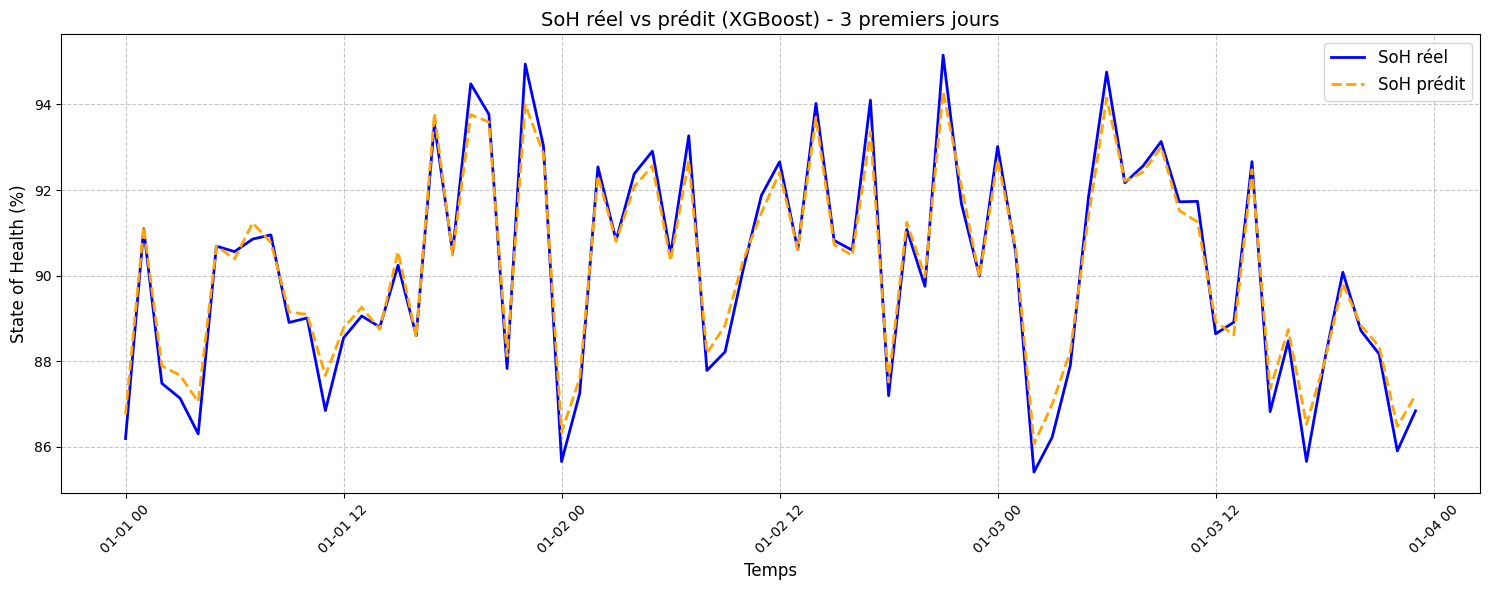

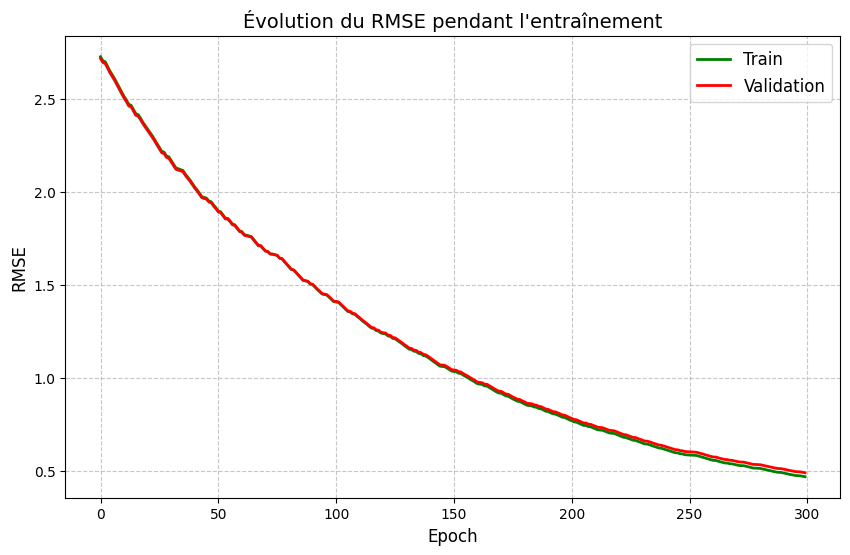

In [1]:
# 1. Importer les bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 2. Charger les données
data = pd.read_csv('/kaggle/input/ev-big/augmented_ev_battery_clean.csv')

# 3. Ajouter Timestamp et Minutes_Elapsed
start_time = pd.Timestamp('2024-01-01 00:00:00')
data['Timestamp'] = [start_time + pd.Timedelta(hours=i) for i in range(len(data))]
data['Minutes_Elapsed'] = (data['Timestamp'] - data['Timestamp'].min()).dt.total_seconds() / 60

# 4. Créer la colonne SoH = 100 - Degradation Rate
data['SoH'] = 100 - pd.to_numeric(data['Degradation Rate (%)'], errors='coerce')
data = data.dropna(subset=['SoH'])
data.drop(columns=['Degradation Rate (%)'], inplace=True)

# 5. Sélectionner les features et la cible
features = [
    'SOC (%)',
    'Voltage (V)',
    'Current (A)',
    'Battery Temp (°C)',
    'Charging Duration (min)',
    'Charging Cycles',
    'Minutes_Elapsed'
]
target = 'SoH'

# 6. Supprimer les lignes avec valeurs manquantes dans features + target
data = data.dropna(subset=features + [target])

# 7. Normalisation des données (optionnel mais recommandé pour XGBoost)
scaler = StandardScaler()
X = data[features]
y = data[target]
X_scaled = scaler.fit_transform(X)

# 8. Split train / validation
X_train, X_valid, y_train, y_valid = train_test_split(X_scaled, y, test_size=0.2, random_state=42, shuffle=True)

# 9. Initialiser et entraîner le modèle XGBoost avec early stopping et meilleurs hyperparamètres
model = XGBRegressor(
    n_estimators=300,           # Augmenté pour plus de stabilité
    learning_rate=0.01,         # Réduit pour éviter les oscillations
    max_depth=4,                # Profondeur modérée pour capturer des motifs complexes
    reg_alpha=0.5,              # Régularisation L1 modérée
    reg_lambda=1.0,             # Régularisation L2 équilibrée
    subsample=0.8,              # Pour réduire le surapprentissage
    colsample_bytree=0.8,       # Pour diversifier les arbres
    random_state=42,
    eval_metric='rmse',
    early_stopping_rounds=10    # Plus patient pour éviter un arrêt prématuré
)

eval_set = [(X_train, y_train), (X_valid, y_valid)]

history = model.fit(
    X_train, y_train,
    eval_set=eval_set,
    verbose=True
)

# 10. Évaluer les performances sur validation
y_pred = model.predict(X_valid)
mae = mean_absolute_error(y_valid, y_pred)
mse = mean_squared_error(y_valid, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_valid, y_pred)

print(f"\n📊 Évaluation XGBoost :")
print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.2f}")

# 11. Prédire SoH sur tout le dataset pour comparer réel vs prédit
data['Predicted_SoH'] = model.predict(X_scaled)

# 12. Extraire données des 3 premiers jours (72 heures)
three_days_data = data.iloc[:72]

# 13. Courbe SoH réel vs prédit (3 premiers jours)
plt.figure(figsize=(15, 6))
plt.plot(three_days_data['Timestamp'], three_days_data['SoH'], label='SoH réel', linewidth=2, color='blue')
plt.plot(three_days_data['Timestamp'], three_days_data['Predicted_SoH'], label='SoH prédit', linestyle='--', linewidth=2, color='orange')
plt.title("SoH réel vs prédit (XGBoost) - 3 premiers jours", fontsize=14)
plt.xlabel("Temps", fontsize=12)
plt.ylabel("State of Health (%)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# 14. Tracer la courbe du RMSE pendant l'entraînement (avec style amélioré)
results = model.evals_result()
epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['validation_0']['rmse'], label='Train', linewidth=2, color='green')
plt.plot(x_axis, results['validation_1']['rmse'], label='Validation', linewidth=2, color='red')
plt.legend(fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Évolution du RMSE pendant l\'entraînement', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [2]:
print(f"Moyenne (y_train): {y_train.mean():.2f}, Écart-type: {y_train.std():.2f}")
# Ajustez ce code pour vérifier vos données
print("\n🔍 Statistiques descriptives :")
print(data[features + [target]].describe())

print("\n📉 Distribution de la cible :")
print(f"SoH moyen: {data[target].mean():.2f}")
print(f"Plage des valeurs: {data[target].min():.2f}-{data[target].max():.2f}")


Moyenne (y_train): 90.36, Écart-type: 2.75

🔍 Statistiques descriptives :
            SOC (%)   Voltage (V)   Current (A)  Battery Temp (°C)  \
count  11712.000000  11712.000000  11712.000000       11712.000000   
mean      54.668952      3.854176     54.956473          29.779778   
std       24.523152      0.311161     24.369428           5.341305   
min        9.516353      2.103366      8.520103          18.620477   
25%       34.179630      3.669510     35.382937          25.307287   
50%       55.339703      3.861312     54.844231          29.684239   
75%       74.995368      4.028579     74.946442          34.121819   
max      100.434048      5.549817    100.506852          40.896863   

       Charging Duration (min)  Charging Cycles  Minutes_Elapsed           SoH  
count             11712.000000     11712.000000     11712.000000  11712.000000  
mean                 65.026518       555.489216    351330.000000     90.364502  
std                  29.989785       247.476090    2

In [3]:
print(f"\n📊 Performance relative :")
print(f"RMSE/Plage totale: {0.41/27.75:.2%}")
print(f"RMSE/Écart-type: {0.41/5.67:.2%}")



📊 Performance relative :
RMSE/Plage totale: 1.48%
RMSE/Écart-type: 7.23%


In [4]:
# Prédictions sur train et test
y_train_pred = model.predict(X_train)
y_valid_pred = model.predict(X_valid)

# Calcul des métriques pour train
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

# Calcul des métriques pour validation
mae_valid = mean_absolute_error(y_valid, y_valid_pred)
rmse_valid = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
r2_valid = r2_score(y_valid, y_valid_pred)

print(f"\n📊 Évaluation LightGBM :")
print(f"Train MAE: {mae_train:.3f} | Train RMSE: {rmse_train:.3f} | Train R²: {r2_train:.3f}")
print(f"Valid MAE: {mae_valid:.3f} | Valid RMSE: {rmse_valid:.3f} | Valid R²: {r2_valid:.3f}")



📊 Évaluation LightGBM :
Train MAE: 0.370 | Train RMSE: 0.469 | Train R²: 0.971
Valid MAE: 0.380 | Valid RMSE: 0.490 | Valid R²: 0.968
